In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

import mne

In [34]:
# Load raw data
data_path = mne.datasets.ssvep.data_path()
bids_fname = (
    data_path / "sub-02" / "ses-01" / "eeg" / "sub-02_ses-01_task-ssvep_eeg.vhdr"
)

raw = mne.io.read_raw_brainvision(bids_fname, preload=True, verbose=False)
raw.info["line_freq"] = 50.0

# Set montage
montage = mne.channels.make_standard_montage("easycap-M1")
raw.set_montage(montage, verbose=False)

# Set common average reference
raw.set_eeg_reference("average", projection=False, verbose=False)

# Apply bandpass filter
raw.filter(l_freq=0.1, h_freq=None, fir_design="firwin", verbose=False)

# Construct epochs
raw.annotations.rename({"Stimulus/S255": "12hz", "Stimulus/S155": "15hz"})
tmin, tmax = -1.0, 20.0  # in s
baseline = None
epochs = mne.Epochs(
    raw,
    event_id=["12hz", "15hz"],
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    verbose=False,
)

In [35]:
tmin = 1.0
tmax = 20.0
fmin = 1.0
fmax = 30.0
sfreq = epochs.info["sfreq"]

spectrum = epochs.compute_psd(
    "welch",
    n_fft=int(sfreq * (tmax - tmin)),
    n_overlap=0,
    n_per_seg=None,
    tmin=tmin,
    tmax=tmax,
    fmin=fmin,
    fmax=fmax,
    window="boxcar",
    verbose=False,
)
psds, freqs = spectrum.get_data(return_freqs=True)

In [36]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """Compute SNR spectrum from PSD spectrum using convolution.

    Parameters
    ----------
    psd : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Data object containing PSD values. Works with arrays as produced by
        MNE's PSD functions or channel/trial subsets.
    noise_n_neighbor_freqs : int
        Number of neighboring frequencies used to compute noise level.
        increment by one to add one frequency bin ON BOTH SIDES
    noise_skip_neighbor_freqs : int
        set this >=1 if you want to exclude the immediately neighboring
        frequency bins in noise level calculation

    Returns
    -------
    snr : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Array containing SNR for all epochs, channels, frequency bins.
        NaN for frequencies on the edges, that do not have enough neighbors on
        one side to calculate SNR.
    """
    # Construct a kernel that calculates the mean of the neighboring
    # frequencies
    averaging_kernel = np.concatenate(
        (
            np.ones(noise_n_neighbor_freqs),
            np.zeros(2 * noise_skip_neighbor_freqs + 1),
            np.ones(noise_n_neighbor_freqs),
        )
    )
    averaging_kernel /= averaging_kernel.sum()

    # Calculate the mean of the neighboring frequencies by convolving with the
    # averaging kernel.
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"), axis=-1, arr=psd
    )

    # The mean is not defined on the edges so we will pad it with nas. The
    # padding needs to be done for the last dimension only so we set it to
    # (0, 0) for the other ones.
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)

    return psd / mean_noise

In [37]:
snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)

/tmp/ipykernel_335828/1831162948.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


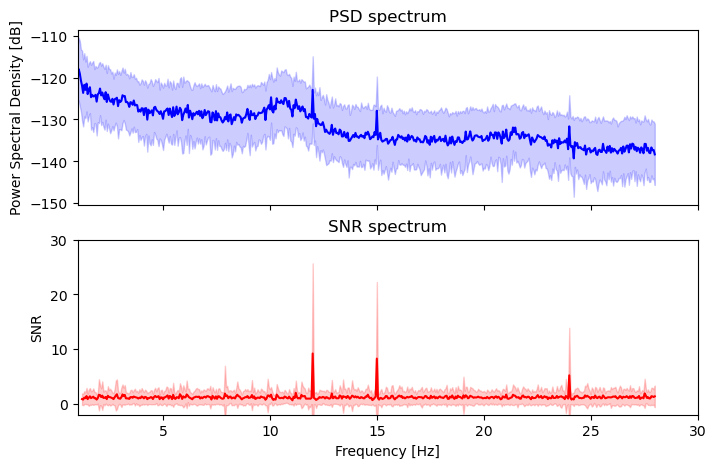

In [38]:
fig, axes = plt.subplots(2, 1, sharex="all", sharey="none", figsize=(8, 5))
freq_range = range(
    np.where(np.floor(freqs) == 1.0)[0][0], np.where(np.ceil(freqs) == fmax - 1)[0][0]
)

psds_plot = 10 * np.log10(psds)
psds_mean = psds_plot.mean(axis=(0, 1))[freq_range]
psds_std = psds_plot.std(axis=(0, 1))[freq_range]
axes[0].plot(freqs[freq_range], psds_mean, color="b")
axes[0].fill_between(
    freqs[freq_range], psds_mean - psds_std, psds_mean + psds_std, color="b", alpha=0.2
)
axes[0].set(title="PSD spectrum", ylabel="Power Spectral Density [dB]")

# SNR spectrum
snr_mean = snrs.mean(axis=(0, 1))[freq_range]
snr_std = snrs.std(axis=(0, 1))[freq_range]

axes[1].plot(freqs[freq_range], snr_mean, color="r")
axes[1].fill_between(
    freqs[freq_range], snr_mean - snr_std, snr_mean + snr_std, color="r", alpha=0.2
)
axes[1].set(
    title="SNR spectrum",
    xlabel="Frequency [Hz]",
    ylabel="SNR",
    ylim=[-2, 30],
    xlim=[fmin, fmax],
)
fig.show()

In [39]:
# define stimulation frequency
stim_freq = 12.0

In [40]:
# find index of frequency bin closest to stimulation frequency
i_bin_12hz = np.argmin(abs(freqs - stim_freq))
# could be updated to support multiple frequencies

# for later, we will already find the 15 Hz bin and the 1st and 2nd harmonic
# for both.
i_bin_24hz = np.argmin(abs(freqs - 24))
i_bin_36hz = np.argmin(abs(freqs - 36))
i_bin_15hz = np.argmin(abs(freqs - 15))
i_bin_30hz = np.argmin(abs(freqs - 30))
i_bin_45hz = np.argmin(abs(freqs - 45))

In [41]:
i_trial_12hz = np.where(epochs.annotations.description == "12hz")[0]
i_trial_15hz = np.where(epochs.annotations.description == "15hz")[0]

In [42]:
# Define different ROIs
roi_vis = [
    "POz",
    "Oz",
    "O1",
    "O2",
    "PO3",
    "PO4",
    "PO7",
    "PO8",
    "PO9",
    "PO10",
    "O9",
    "O10",
]  # visual roi

# Find corresponding indices using mne.pick_types()
picks_roi_vis = mne.pick_types(
    epochs.info, eeg=True, stim=False, exclude="bads", selection=roi_vis
)

In [43]:
snrs_target = snrs[i_trial_12hz, :, i_bin_12hz][:, picks_roi_vis]
print("sub 2, 12 Hz trials, SNR at 12 Hz")
print(f"average SNR (occipital ROI): {snrs_target.mean()}")

sub 2, 12 Hz trials, SNR at 12 Hz
average SNR (occipital ROI): 41.6936554171862


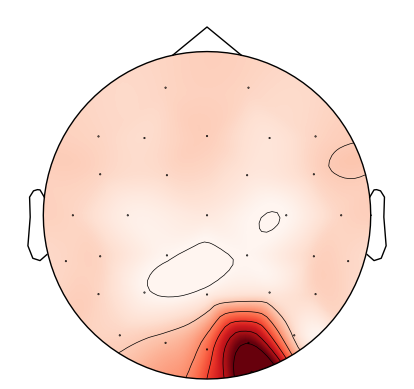

sub 2, 12 Hz trials, SNR at 12 Hz
average SNR (all channels): 16.98590219033801
average SNR (occipital ROI): 41.6936554171862
12 Hz SNR in occipital ROI is significantly larger than 12 Hz SNR over all channels: t = 6.950, p = 6.681036517815686e-05


In [44]:
# get average SNR at 12 Hz for ALL channels
snrs_12hz = snrs[i_trial_12hz, :, i_bin_12hz]
snrs_12hz_chaverage = snrs_12hz.mean(axis=0)

# plot SNR topography
fig, ax = plt.subplots(1)
mne.viz.plot_topomap(snrs_12hz_chaverage, epochs.info, vlim=(1, None), axes=ax)

print("sub 2, 12 Hz trials, SNR at 12 Hz")
print(f"average SNR (all channels): {snrs_12hz_chaverage.mean()}")
print(f"average SNR (occipital ROI): {snrs_target.mean()}")

tstat_roi_vs_scalp = ttest_rel(snrs_target.mean(axis=1), snrs_12hz.mean(axis=1))
print(
    "12 Hz SNR in occipital ROI is significantly larger than 12 Hz SNR over all "
    f"channels: t = {tstat_roi_vs_scalp[0]:.3f}, p = {tstat_roi_vs_scalp[1]}"
)

/tmp/ipykernel_335828/3642232202.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


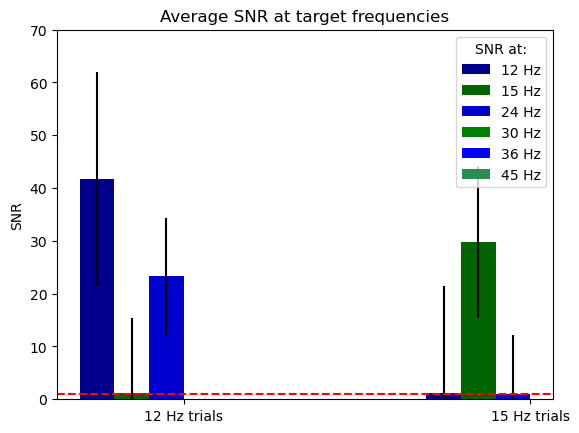

In [45]:
snrs_roi = snrs[:, picks_roi_vis, :].mean(axis=1)

freq_plot = [12, 15, 24, 30, 36, 45]
color_plot = ["darkblue", "darkgreen", "mediumblue", "green", "blue", "seagreen"]
xpos_plot = [-5.0 / 12, -3.0 / 12, -1.0 / 12, 1.0 / 12, 3.0 / 12, 5.0 / 12]
fig, ax = plt.subplots()
labels = ["12 Hz trials", "15 Hz trials"]
x = np.arange(len(labels))  # the label locations
width = 0.6  # the width of the bars
res = dict()

# loop to plot SNRs at stimulation frequencies and harmonics
for i, f in enumerate(freq_plot):
    # extract snrs
    stim_12hz_tmp = snrs_roi[i_trial_12hz, np.argmin(abs(freqs - f))]
    stim_15hz_tmp = snrs_roi[i_trial_15hz, np.argmin(abs(freqs - f))]
    SNR_tmp = [stim_12hz_tmp.mean(), stim_15hz_tmp.mean()]
    # plot (with std)
    ax.bar(
        x + width * xpos_plot[i],
        SNR_tmp,
        width / len(freq_plot),
        yerr=np.std(SNR_tmp),
        label=f"{f} Hz SNR",
        color=color_plot[i],
    )
    # store results for statistical comparison
    res[f"stim_12hz_snrs_{f}hz"] = stim_12hz_tmp
    res[f"stim_15hz_snrs_{f}hz"] = stim_15hz_tmp

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel("SNR")
ax.set_title("Average SNR at target frequencies")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend([f"{f} Hz" for f in freq_plot], title="SNR at:")
ax.set_ylim([0, 70])
ax.axhline(1, ls="--", c="r")
fig.show()

In [46]:
# Compare 12 Hz and 15 Hz SNR in trials after averaging over channels

tstat_12hz_trial_stim = ttest_rel(
    res["stim_12hz_snrs_12hz"], res["stim_12hz_snrs_15hz"]
)
print(
    "12 Hz Trials: 12 Hz SNR is significantly higher than 15 Hz SNR: t = "
    f"{tstat_12hz_trial_stim[0]:.3f}, p = {tstat_12hz_trial_stim[1]}"
)

tstat_12hz_trial_1st_harmonic = ttest_rel(
    res["stim_12hz_snrs_24hz"], res["stim_12hz_snrs_30hz"]
)
print(
    "12 Hz Trials: 24 Hz SNR is significantly higher than 30 Hz SNR: t = "
    f"{tstat_12hz_trial_1st_harmonic[0]:.3f}, p = {tstat_12hz_trial_1st_harmonic[1]}"
)

tstat_12hz_trial_2nd_harmonic = ttest_rel(
    res["stim_12hz_snrs_36hz"], res["stim_12hz_snrs_45hz"]
)
print(
    "12 Hz Trials: 36 Hz SNR is significantly higher than 45 Hz SNR: t = "
    f"{tstat_12hz_trial_2nd_harmonic[0]:.3f}, p = {tstat_12hz_trial_2nd_harmonic[1]}"
)

print()
tstat_15hz_trial_stim = ttest_rel(
    res["stim_15hz_snrs_12hz"], res["stim_15hz_snrs_15hz"]
)
print(
    "15 Hz trials: 12 Hz SNR is significantly lower than 15 Hz SNR: t = "
    f"{tstat_15hz_trial_stim[0]:.3f}, p = {tstat_15hz_trial_stim[1]}"
)

tstat_15hz_trial_1st_harmonic = ttest_rel(
    res["stim_15hz_snrs_24hz"], res["stim_15hz_snrs_30hz"]
)
print(
    "15 Hz trials: 24 Hz SNR is significantly lower than 30 Hz SNR: t = "
    f"{tstat_15hz_trial_1st_harmonic[0]:.3f}, p = {tstat_15hz_trial_1st_harmonic[1]}"
)

tstat_15hz_trial_2nd_harmonic = ttest_rel(
    res["stim_15hz_snrs_36hz"], res["stim_15hz_snrs_45hz"]
)
print(
    "15 Hz trials: 36 Hz SNR is significantly lower than 45 Hz SNR: t = "
    f"{tstat_15hz_trial_2nd_harmonic[0]:.3f}, p = {tstat_15hz_trial_2nd_harmonic[1]}"
)

12 Hz Trials: 12 Hz SNR is significantly higher than 15 Hz SNR: t = 7.510, p = 3.6543191814520666e-05
12 Hz Trials: 24 Hz SNR is significantly higher than 30 Hz SNR: t = nan, p = nan
12 Hz Trials: 36 Hz SNR is significantly higher than 45 Hz SNR: t = nan, p = nan

15 Hz trials: 12 Hz SNR is significantly lower than 15 Hz SNR: t = -5.692, p = 0.000297367500462259
15 Hz trials: 24 Hz SNR is significantly lower than 30 Hz SNR: t = nan, p = nan
15 Hz trials: 36 Hz SNR is significantly lower than 45 Hz SNR: t = nan, p = nan


/tmp/ipykernel_335828/4223249206.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


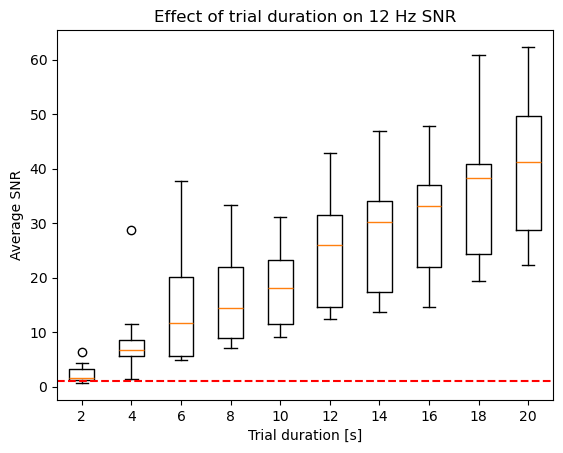

In [47]:
stim_bandwidth = 0.5

# shorten data and welch window
window_lengths = [i for i in range(2, 21, 2)]
window_snrs = [[]] * len(window_lengths)
for i_win, win in enumerate(window_lengths):
    # compute spectrogram
    this_spectrum = epochs["12hz"].compute_psd(
        "welch",
        n_fft=int(sfreq * win),
        n_overlap=0,
        n_per_seg=None,
        tmin=0,
        tmax=win,
        window="boxcar",
        fmin=fmin,
        fmax=fmax,
        verbose=False,
    )
    windowed_psd, windowed_freqs = this_spectrum.get_data(return_freqs=True)
    # define a bandwidth of 1 Hz around stimfreq for SNR computation
    bin_width = windowed_freqs[1] - windowed_freqs[0]
    skip_neighbor_freqs = (
        round((stim_bandwidth / 2) / bin_width - bin_width / 2.0 - 0.5)
        if (bin_width < stim_bandwidth)
        else 0
    )
    n_neighbor_freqs = int(
        (
            sum((windowed_freqs <= 13) & (windowed_freqs >= 11))
            - 1
            - 2 * skip_neighbor_freqs
        )
        / 2
    )
    # compute snr
    windowed_snrs = snr_spectrum(
        windowed_psd,
        noise_n_neighbor_freqs=n_neighbor_freqs if (n_neighbor_freqs > 0) else 1,
        noise_skip_neighbor_freqs=skip_neighbor_freqs,
    )
    window_snrs[i_win] = windowed_snrs[
        :, picks_roi_vis, np.argmin(abs(windowed_freqs - 12.0))
    ].mean(axis=1)

fig, ax = plt.subplots(1)
ax.boxplot(window_snrs, tick_labels=window_lengths, orientation="vertical")
ax.set(
    title="Effect of trial duration on 12 Hz SNR",
    ylabel="Average SNR",
    xlabel="Trial duration [s]",
)
ax.axhline(1, ls="--", c="r")
fig.show()

/tmp/ipykernel_335828/939895662.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


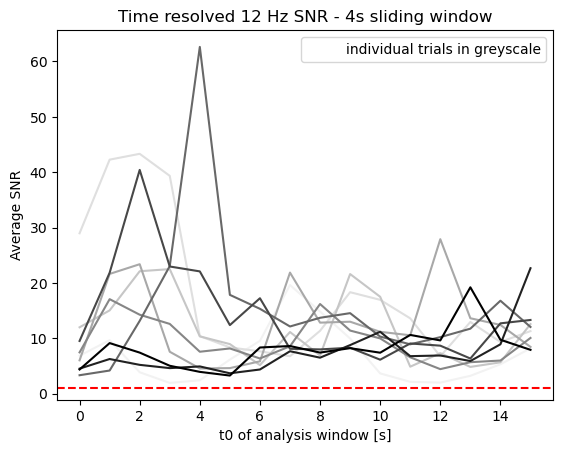

In [48]:
# 3s sliding window
window_length = 4
window_starts = [i for i in range(20 - window_length)]
window_snrs = [[]] * len(window_starts)

for i_win, win in enumerate(window_starts):
    # compute spectrogram
    this_spectrum = epochs["12hz"].compute_psd(
        "welch",
        n_fft=int(sfreq * window_length) - 1,
        n_overlap=0,
        n_per_seg=None,
        window="boxcar",
        tmin=win,
        tmax=win + window_length,
        fmin=fmin,
        fmax=fmax,
        verbose=False,
    )
    windowed_psd, windowed_freqs = this_spectrum.get_data(return_freqs=True)
    # define a bandwidth of 1 Hz around stimfreq for SNR computation
    bin_width = windowed_freqs[1] - windowed_freqs[0]
    skip_neighbor_freqs = (
        round((stim_bandwidth / 2) / bin_width - bin_width / 2.0 - 0.5)
        if (bin_width < stim_bandwidth)
        else 0
    )
    n_neighbor_freqs = int(
        (
            sum((windowed_freqs <= 13) & (windowed_freqs >= 11))
            - 1
            - 2 * skip_neighbor_freqs
        )
        / 2
    )
    # compute snr
    windowed_snrs = snr_spectrum(
        windowed_psd,
        noise_n_neighbor_freqs=n_neighbor_freqs if (n_neighbor_freqs > 0) else 1,
        noise_skip_neighbor_freqs=skip_neighbor_freqs,
    )
    window_snrs[i_win] = windowed_snrs[
        :, picks_roi_vis, np.argmin(abs(windowed_freqs - 12.0))
    ].mean(axis=1)

fig, ax = plt.subplots(1)
colors = plt.colormaps["Greys"](np.linspace(0, 1, 10))
for i in range(10):
    ax.plot(window_starts, np.array(window_snrs)[:, i], color=colors[i])
ax.set(
    title=f"Time resolved 12 Hz SNR - {window_length}s sliding window",
    ylabel="Average SNR",
    xlabel="t0 of analysis window [s]",
)
ax.axhline(1, ls="--", c="r")
ax.legend(["individual trials in greyscale"])
fig.show()